In [ ]:
# ================================
# STEP 1: Upload Dataset (Method 2)
# ================================
from google.colab import files
uploaded = files.upload()


Saving Crop_recommendation.csv to Crop_recommendation (1).csv


In [ ]:
# ================================
# STEP 2: Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier


In [ ]:
# ================================
# STEP 3: Load Dataset
# ================================
df = pd.read_csv("Crop_recommendation.csv")

print("Dataset Loaded Successfully!\n")
print(df.head())

Dataset Loaded Successfully!

    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


In [ ]:

# ================================
# STEP 4: Features & Target
# ================================
X = df.drop("label", axis=1)
y = df["label"]

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
# ================================
# STEP 5: Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# ================================
# ACCURACY FUNCTION
# ================================
def print_accuracy_details(model_name, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    total = len(y_test)
    correct = (y_test == y_pred).sum()

    print(f"\n{model_name} Results:")
    print(f"Accuracy: {round(acc*100, 2)}%")
    print(f"Correct Predictions: {correct}/{total}")
    print(f"Wrong Predictions: {total - correct}/{total}")

In [ ]:
# ================================
# MODEL 1: Random Forest
# ================================
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print_accuracy_details("Random Forest", y_test, y_pred_rf)
print(classification_report(y_test, y_pred_rf))


Random Forest Results:
Accuracy: 99.32%
Correct Predictions: 437/440
Wrong Predictions: 3/440
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      0.96      0.98        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1

In [ ]:
# ================================
# MODEL 2: Decision Tree
# ================================
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print_accuracy_details("Decision Tree", y_test, y_pred_dt)
print(classification_report(y_test, y_pred_dt))



Decision Tree Results:
Accuracy: 98.41%
Correct Predictions: 433/440
Wrong Predictions: 7/440
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.91      0.87      0.89        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      0.92      0.96        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1

In [ ]:
# ================================
# MODEL 3: KNN
# ================================
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print_accuracy_details("KNN", y_test, y_pred_knn)
print(classification_report(y_test, y_pred_knn))



KNN Results:
Accuracy: 97.05%
Correct Predictions: 427/440
Wrong Predictions: 13/440
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      0.94      0.97        17
           6       0.94      1.00      0.97        17
           7       1.00      1.00      1.00        14
           8       0.76      0.96      0.85        23
           9       0.95      1.00      0.98        20
          10       0.85      1.00      0.92        11
          11       1.00      0.95      0.98        21
          12       1.00      1.00      1.00        19
          13       1.00      0.92      0.96        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00      

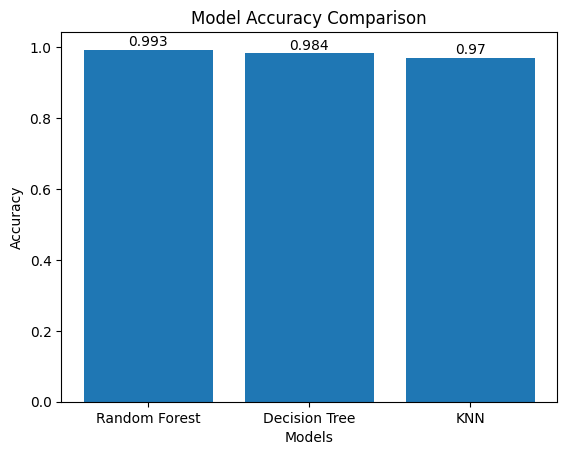

In [ ]:
# ================================
# MODEL COMPARISON GRAPH
# ================================
models = ['Random Forest', 'Decision Tree', 'KNN']
accuracies = [
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_knn)
]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, str(round(v, 3)), ha='center')

plt.show()

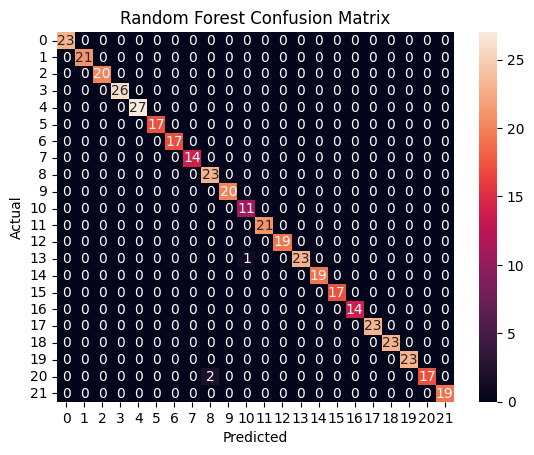

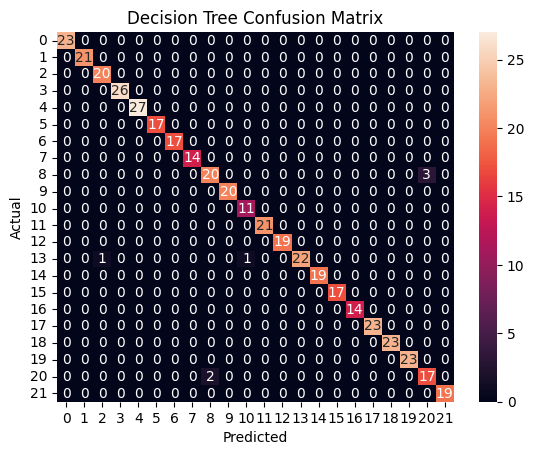

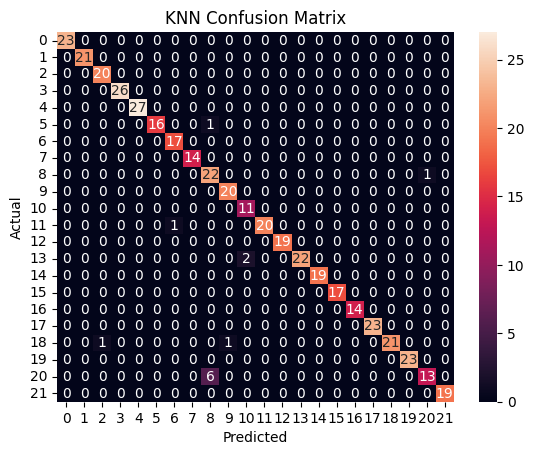

In [ ]:
# ================================
# CONFUSION MATRIX
# ================================
def plot_confusion_matrix(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf, "Random Forest Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_dt, "Decision Tree Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_knn, "KNN Confusion Matrix")


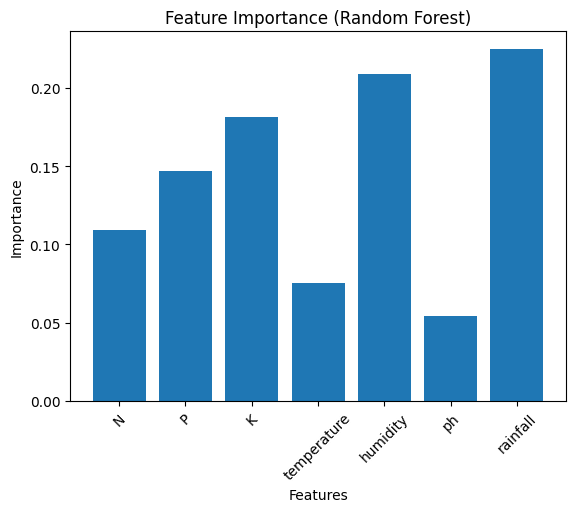

In [ ]:
# ================================
# FEATURE IMPORTANCE (Random Forest)
# ================================
importances = rf.feature_importances_
features = X.columns

plt.figure()
plt.bar(features, importances)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# ================================
# PREDICTION FUNCTION
# ================================
def predict_crop(N, P, K, temp, humidity, ph, rainfall):
    data = np.array([[N, P, K, temp, humidity, ph, rainfall]])
    prediction = rf.predict(data)
    return le.inverse_transform(prediction)

# Example Prediction
print("\nRecommended Crop:",
      predict_crop(90, 40, 40, 25, 80, 6.5, 200))


Recommended Crop: ['jute']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
